In [1]:
import os, sys
import numpy as np
import pandas as pd
import pickle as pk
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib as mpl
from itertools import product
from rich import print as rprint
from scipy.optimize import curve_fit as cfit

sys.path.insert(0, '../scripts_analysis')
from analysis import *
from peaks import  detect_peaks
from util import *

plt.style.use('dark_background')
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.family'] = 'Noto Sans'

simTypes = {
    'control':     dict(d='control', r='result.dat', v='vesData.dat'),
    'without cross-talk': dict(d='control_eachCa', r='sresult_RRP_{}.dat', v='svesData_RRP_{}.dat'),
    'nonsatBuffer': dict(d='control_unsatBuffer', r='result.dat', v='vesData.dat'),
    'syt7KO':      dict(d='syt7KO', r='result.dat', v='vesData.dat')
}
#print(simTypes)

resultPath = "../data/"
figPath = "../plots/ap_counting/"
setupLoc = '../model_mcell'

designs = np.genfromtxt(os.path.join(setupLoc, 'representative_designs.txt'), dtype=str)

for i,d in enumerate(designs): print(i, d)

0 nVDCC_2_dVAZ_60_nAZ_15_RRP_35_ISI_20_nAP_10
1 nVDCC_3_dVAZ_100_nAZ_29_RRP_55_ISI_20_nAP_10
2 nVDCC_3_dVAZ_60_nAZ_9_RRP_20_ISI_20_nAP_10
3 nVDCC_3_dVAZ_80_nAZ_35_RRP_30_ISI_20_nAP_10
4 nVDCC_4_dVAZ_100_nAZ_19_RRP_50_ISI_20_nAP_10
5 nVDCC_4_dVAZ_120_nAZ_25_RRP_55_ISI_20_nAP_10
6 nVDCC_4_dVAZ_120_nAZ_33_RRP_50_ISI_20_nAP_10
7 nVDCC_4_dVAZ_80_nAZ_21_RRP_30_ISI_20_nAP_10
8 nVDCC_5_dVAZ_100_nAZ_11_RRP_50_ISI_20_nAP_10
9 nVDCC_5_dVAZ_120_nAZ_15_RRP_50_ISI_20_nAP_10
10 nVDCC_5_dVAZ_120_nAZ_23_RRP_40_ISI_20_nAP_10
11 nVDCC_5_dVAZ_120_nAZ_35_RRP_25_ISI_20_nAP_10
12 nVDCC_5_dVAZ_220_nAZ_35_RRP_50_ISI_20_nAP_10
13 nVDCC_5_dVAZ_80_nAZ_21_RRP_10_ISI_20_nAP_10
14 nVDCC_5_dVAZ_80_nAZ_29_RRP_10_ISI_20_nAP_10
15 nVDCC_6_dVAZ_140_nAZ_25_RRP_30_ISI_20_nAP_10
16 nVDCC_6_dVAZ_160_nAZ_19_RRP_55_ISI_20_nAP_10
17 nVDCC_6_dVAZ_160_nAZ_35_RRP_25_ISI_20_nAP_10
18 nVDCC_6_dVAZ_200_nAZ_29_RRP_50_ISI_20_nAP_10
19 nVDCC_6_dVAZ_80_nAZ_17_RRP_10_ISI_20_nAP_10
20 nVDCC_7_dVAZ_100_nAZ_33_RRP_5_ISI_20_nAP_10
21 nVDCC_7_

# AP probability

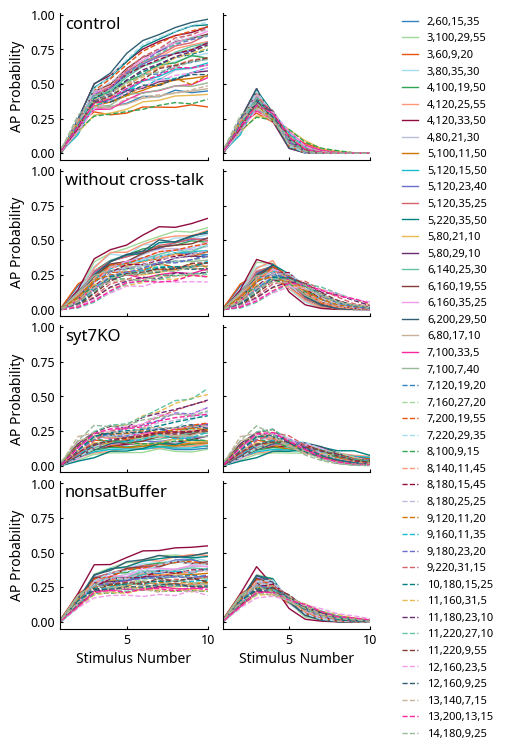

In [2]:
f, ax = plt.subplots(4, 2, sharex=True, sharey=True, figsize=(4,8))
                     #gridspec_kw={'width_ratios': [5, 2]})
f.subplots_adjust(wspace=0.1, hspace=0.06)

ls = ['-', '--']
lw = 1
ISI, nAP = 20, 10
for i,(stlabel,stinfo) in enumerate(simTypes.items()):
    for j,design in enumerate(designs[:]):
        # label = str([int(a) for a in re.findall(r'\d+', design)[:-2]])[1:-1]
        st = stinfo['d']
        # tt = stinfo['tt']
        #print(stlabel)
        # inf = os.path.join(resultPath, st, design, tt+'apTimes.dat')

        if stlabel == 'without cross-talk':
            design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]
        ca3p = os.path.join(resultPath, st, design, 'CA3p.pk')
        label = ','.join(list(getSimInfo(design, skip=0).values())[:-2])
        apProb, ap1Prob = getAPprob(ca3p)

        ## AP Probability
        ax[i,0].plot(range(1,11), apProb, lw=lw, linestyle=ls[int(j/22)], 
                   color=cpall[j%22], label=label)
        ax[i,0].set_ylabel('AP Probability', fontsize=10)

        ## 1st AP
        ax[i,1].plot(range(1, nAP+1), ap1Prob, lw=lw, linestyle=ls[int(j/22)],
                     color=cpall[j%22], label=label)

    ax[i,0].set_xlim(0.9,10)
    # ax[i,0].set_ylim(0,1)
    # ax[i,0].set_yticks([0, 0.5, 1.0])

    ax[i,1].set_xlim(0.9,10)
    # ax[i,1].set_ylim(0, np.ceil(ax[0,1].get_ylim()[1]*9.9)/10)
    # ax[i,1].set_yticks(np.arange(0, np.ceil(ax[0,1].get_ylim()[1]*9.9)/10+0.0001, 0.1))

    ax[i,0].text(1.2, 0.9, stlabel, fontsize=12)

ax[0,1].legend(frameon=False, ncol=1, handlelength=1.4, fontsize=8,
               loc='upper right', bbox_to_anchor=(1.9, 1.04))
ax[-1,0].set_xlabel("Stimulus Number", fontsize=10)
ax[-1,1].set_xlabel("Stimulus Number", fontsize=10)
for axis in ax.ravel():
    axis.spines["right"].set_visible(False)
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis=u'both', which=u'both', length=2, direction='in', labelsize=9)

# plt.savefig(os.path.join(figPath, f'ap_probability.svg'), 
#             dpi=300, bbox_inches='tight', transparent=True)
plt.show()

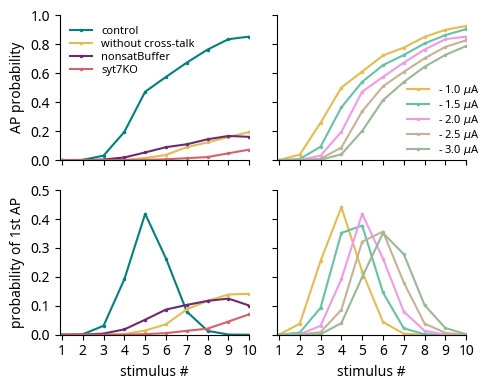

In [22]:
design = designs[25]
fig, ax = plt.subplots(2,2, figsize=(5,4), sharex=True)
fig.subplots_adjust(wspace=0.4, hspace=0.1)

sim_color = {
    'control': 12,
    'without cross-talk': 13,
    'nonsatBuffer': 14,
    'syt7KO': 11
}

for simType in simTypes.keys():
    if simType == 'without cross-talk':
        _design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]
        ca3p = os.path.join(dataPath, simTypes[simType]['d'], _design, 'CA3p_Isapp_2.0.pk')
    else:
        ca3p = os.path.join(dataPath, simTypes[simType]['d'], design, 'CA3p_Isapp_2.0.pk')
    
    with open(ca3p, "rb") as infile:
        ca3 = pk.load(infile)

    apProb, ap1Prob = getAPprob(ca3p)
    ax[0,0].plot(range(1, 11), apProb, marker=".", color=cpall[sim_color[simType]], markersize=3, label=simType)
    ax[1,0].plot(range(1, 11), ap1Prob, marker=".",color=cpall[sim_color[simType]], markersize=3, label=r'I = -2 $\mu$A')


ax[0,0].set_ylabel("AP probability")
# ax[0,0].set_xlabel("stimulus number") # spike number, vlines for spikes instead of ticks
ax[0,0].set_xlim([0.8, 10])
ax[0,0].set_xticks(range(1,11))
ax[0,0].set_ylim([0, 1])
ax[0,0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax[0,0].legend(frameon=False, labelspacing=0.2, fontsize=8)
# ax[0,0].set_title(r"I$_{inh}$ = - 2 $\mu$A")

ax[1,0].set_ylabel("probability of 1st AP")
ax[1,0].set_xlabel("stimulus #")
ax[1,0].set_xlim([0.8, 10])
ax[1,0].set_ylim([0, 0.5])
ax[1,0].set_xticks(range(1, 11))

#### Effect of inhibition
simType = 'control'
for inh in [1.0, 1.5, 2.0, 2.5, 3.0]:
    CA3p_data = f'CA3p_Isapp_{inh:0.1f}.pk'
    if simType == 'without cross-talk':
        _design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]
        ca3p = os.path.join(dataPath, simTypes[simType]['d'], _design, CA3p_data)
    else:
        ca3p = os.path.join(dataPath, simTypes[simType]['d'], design, CA3p_data)
    
    with open(ca3p, "rb") as infile:
        ca3 = pk.load(infile)

    apProb, ap1Prob = getAPprob(ca3p)
    ax[0,1].plot(range(1, 11), apProb, marker=".", markersize=3, color=cpall[int(4*inh)+9], label=rf'- {inh} $\mu$A')
    ax[1,1].plot(range(1, 11), ap1Prob, marker=".", markersize=3, color=cpall[int(4*inh)+9], label=rf'- {inh} $\mu$A')

# ax[0,1].set_ylabel("AP probability")
ax[0,1].set_xlim([.9, 10])
ax[0,1].set_xticks(range(1, 11))
ax[0,1].set_ylim([0, 1])
ax[0,1].set_yticklabels([])
ax[0,1].legend(frameon=False, labelspacing=0.1, fontsize=8, 
               loc='lower right', bbox_to_anchor=(1.12, -0.05))
# ax[0,1].set_title("Control")

# ax[1,1].set_ylabel("Probability of 1st AP")
ax[1,1].set_xlabel("stimulus #")
ax[1,1].set_xlim([.9, 10])
ax[1,1].set_ylim([0, 0.5])
ax[1,1].set_xticks(range(1, 11))
ax[1,1].set_yticklabels([])

for axis in ax.ravel():
    axis.spines[["right", "top"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(figPath, f'AP_prob_single_design.svg'), 
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# AP probability of single desgn

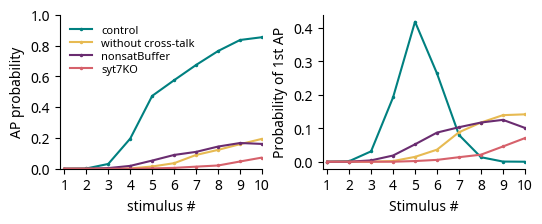

In [21]:
design = designs[25]
fig, ax = plt.subplots(1,2, figsize=(6,2))
fig.subplots_adjust(wspace=0.3, hspace=0.06)

sim_color = {
    'control': 12,
    'without cross-talk': 13,
    'nonsatBuffer': 14,
    'syt7KO': 11
}

for simType in simTypes.keys():
    if simType == 'without cross-talk':
        _design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]
        ca3p = os.path.join(dataPath, simTypes[simType]['d'], _design, 'CA3p_Isapp_2.0.pk')
    else:
        ca3p = os.path.join(dataPath, simTypes[simType]['d'], design, 'CA3p_Isapp_2.0.pk')
    
    with open(ca3p, "rb") as infile:
        ca3 = pk.load(infile)

    apProb, ap1Prob = getAPprob(ca3p)
    ax[0].plot(range(1, 11), apProb, marker=".", color=cpall[sim_color[simType]], markersize=3, label=simType)
    ax[1].plot(range(1, 11), ap1Prob, marker=".",color=cpall[sim_color[simType]], markersize=3, label=r'I = -2 $\mu$A')


ax[0].set_ylabel("AP probability")
ax[0].set_xlabel("stimulus #") # spike number, vlines for spikes instead of ticks
ax[0].set_xlim([0.8, 10])
ax[0].set_xticks(range(1,11))
ax[0].set_ylim([0, 1])
ax[0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax[0].legend(frameon=False, labelspacing=0.2, fontsize=8)
ax[0].spines[["right", "top"]].set_visible(False)
# axis.spines["top"].set_visible(False)
# print(ca3.keys())

# Second subplot: 1st AP probability
ax[1].set_ylabel("Probability of 1st AP")
ax[1].set_xlabel("Stimulus #")
ax[1].set_xlim([0.8, 10])
ax[1].set_xticks(range(1, 11))
ax[1].spines[["right", "top"]].set_visible(False)

plt.savefig(os.path.join(figPath, f'ap_probability_single_design.svg'), 
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# Effect of Inhibition

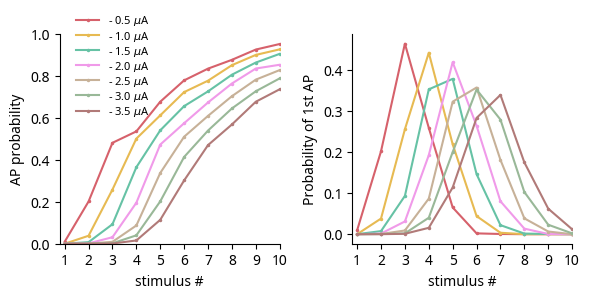

In [ ]:
design = designs[25]
fig, ax = plt.subplots(1,2, figsize=(6,3), sharex=True)
fig.subplots_adjust(wspace=0.3, hspace=0.0)

simType = 'control'
for inh in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]:
    CA3p_data = f'CA3p_Isapp_{inh:0.1f}.pk'
    if simType == 'without cross-talk':
        _design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]
        ca3p = os.path.join(dataPath, simTypes[simType]['d'], _design, CA3p_data)
    else:
        ca3p = os.path.join(dataPath, simTypes[simType]['d'], design, CA3p_data)
    
    with open(ca3p, "rb") as infile:
        ca3 = pk.load(infile)

    apProb, ap1Prob = getAPprob(ca3p)
    ax[0].plot(range(1, 11), apProb, marker=".", markersize=3, color=cpall[int(4*inh)+9], label=rf'- {inh} $\mu$A')
    ax[1].plot(range(1, 11), ap1Prob, marker=".", markersize=3, color=cpall[int(4*inh)+9], label=rf'- {inh} $\mu$A')

# First subplot: AP probability
ax[0].set_ylabel("AP probability")
ax[0].set_xlabel("stimulus #")
ax[0].set_xlim([0.8, 10])
ax[0].set_xticks(range(1, 11))
ax[0].set_ylim([0, 1])
ax[0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax[0].legend(frameon=False, labelspacing=0.1, fontsize=8, bbox_to_anchor=(0.45, 0.55))
ax[0].spines[["right", "top"]].set_visible(False)

# Second subplot: 1st AP probability
ax[1].set_ylabel("Probability of 1st AP")
ax[1].set_xlabel("stimulus #")
ax[1].set_xlim([0.8, 10])
ax[1].set_xticks(range(1, 11))
ax[1].spines[["right", "top"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(figPath, f'effect_of_inhibition.svg'), 
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# Single AP Probability Comparision

In [18]:
P_AP10 = {}
ISI, nAP = 20, 10
for i,(stlabel,stinfo) in enumerate(simTypes.items()):
    AP10 = []
    for j,design in enumerate(designs[:]):
        # label = str([int(a) for a in re.findall(r'\d+', design)[:-2]])[1:-1]
        st = stinfo['d']
        # tt = stinfo['tt']
        #print(stlabel)
        # inf = os.path.join(resultPath, st, design, tt+'apTimes.dat')

        if stlabel == 'without cross-talk':
            design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]
        ca3p = os.path.join(resultPath, st, design, 'CA3p.pk')
        label = ','.join(list(getSimInfo(design, skip=0).values())[:-2])
        apProb, ap1Prob = getAPprob(ca3p)
        # print(apProb, stlabel, design)
        AP10.append(float(apProb[9]))

    P_AP10.update({stlabel: AP10})

P_AP10 = pd.DataFrame(P_AP10)
P_AP10.head()

,control,without cross-talk,syt7KO,nonsatBuffer
0,0.4495,0.3945,0.1265,0.3870
1,0.7955,0.5905,0.1180,0.4990
2,0.3345,0.3120,0.1390,0.2860
3,0.7215,0.5410,0.1565,0.4385
4,0.6870,0.4850,0.1630,0.4165


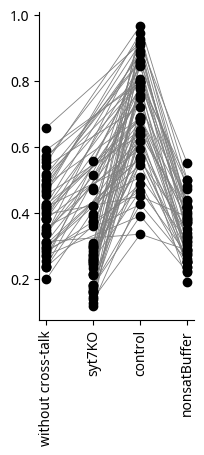

In [20]:
order = ['without cross-talk', 'syt7KO', 'control', 'nonsatBuffer']
fig, axis = plt.subplots(figsize=(2, 4))

change_plot(P_AP10, key='control', order=order, axis=axis, lc='gray', lw=0.6,
            save_loc=os.path.join(figPath, f'ap_probability_10_compare.svg'))

# 4D plot of P_AP10

In [5]:
category_info_path = os.path.join(dataPath, 'control_eachCa/category_info.pk')
if os.path.exists(category_info_path):
    with open(category_info_path, "rb") as infile:
        category_info = pk.load(infile)
else:
    rprint(f"[red]File not found: {category_info_path}[/red]")

In [6]:
category_info[0,0,0,0].keys()

dict_keys(['n_designs', 'rep_design_max', 'rep_design_median', 'pr', 'rel', 'mvu', 'facil', 'avg_ca_peak', 'avg_res_ca', 'avg_ca_syt7_peak', 'avg_ca_syt1_peak', 'rep_design_min', 'avg_peak_overlap', 'avg_basal_overlap'])

In [7]:
key = 'rep_design_median'
pAP10 = np.zeros(category_info.shape)
for nv, dv, naz, rrp in product(range(3), repeat=4):
    try:
        design = category_info[nv, dv, naz, rrp][key]
        # print(design)
        stlabel = 'control'
        stinfo = simTypes[stlabel]
        st = stinfo['d']

        if stlabel == 'without cross-talk':
            design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]
        ca3p = os.path.join(resultPath, st, design, 'CA3p.pk')

        apProb, ap1Prob = getAPprob(ca3p)
        pAP10[nv, dv, naz, rrp] = apProb[-1]

    except KeyError:
        pass
        pAP10[nv, dv, naz, rrp] = 0
    # break
# pAP10

In [8]:
figsize_4d = (5,4.1)

ticklabelsize_4d = 8
labelsize_4d = 10
sublabelsize_4d = 8
textsize_4d = 8

cases = ['Low', 'Mid', 'High']

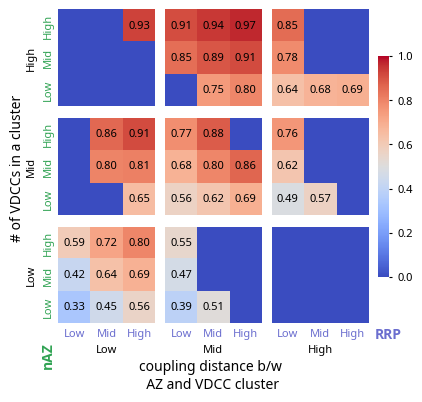

In [10]:
fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=figsize_4d)
fig.subplots_adjust(wspace=0.1, hspace=0.1)

for axis in ax[-1,:]:
    axis.set_xticks(range(3))
    axis.set_xticklabels(cases, color=cpdark[5], fontsize=ticklabelsize_4d)

for axis in ax[:,0]:
    axis.set_yticks(range(3))
    axis.set_yticklabels(cases, color=cpdark[2], fontsize=ticklabelsize_4d,
                         rotation=90, ha="right", va="center")

for nv, dv in product(range(3), range(3)):
    ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
    
    imdata = pAP10[dv, 2-nv]
    im = ax[nv][dv].imshow(
        imdata,
        vmin=0,
        vmax=1,
        cmap='coolwarm', 
        origin='lower'
    )
    
    for i in range(3):
        for j in range(3):
            if imdata[i, j] > 0.001:
                text = ax[nv][dv].text(j, i, f'{imdata[i, j]:0.2f}', fontsize=textsize_4d,
                                       ha="center", va="center", color="black")
    if nv==2:
        ax[nv][dv].set_xlabel(cases[dv], fontsize=sublabelsize_4d)
    if dv==0:
        ax[nv][dv].set_ylabel(cases[2-nv], fontsize=sublabelsize_4d)
       
    ax[nv][dv].spines[["bottom","top","right","left"]].set_visible(False)
    
ax[-1,0].text(-1.05, -1.8, 'nAZ', size=labelsize_4d, rotation=90, color=cpdark[2], fontweight='bold')
ax[-1,-1].text(2.7, -0.96, 'RRP', size=labelsize_4d, color=cpdark[5], fontweight='bold')
ax[-1,1].text(-1.3, -2.5, 'coupling distance b/w\n  AZ and VDCC cluster', size=labelsize_4d, color=cpdark[-1])
ax[1,0].text(-2, -1.2, '# of VDCCs in a cluster', size=labelsize_4d, rotation=90, color=cpdark[-1])

cb = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.7, anchor=(-0.2,0.5))
cb.outline.set_visible(False)
cb.ax.tick_params(size=2, labelsize=ticklabelsize_4d)
plt.show()

fig.savefig(os.path.join(figPath, 'P_AP10_4D.svg'),
          dpi=300, bbox_inches='tight', transparent=True)

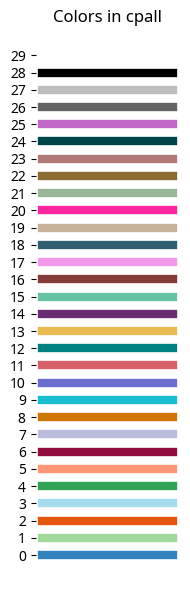

In [83]:
fig, ax = plt.subplots(figsize=(2,6))
for i, color in enumerate(cpall):
    ax.plot([0, 1], [i, i], color=color, linewidth=6, label=f'{i}: {color}')
ax.set_yticks(range(len(cpall)))
ax.set_yticklabels([f'{i}' for i in range(len(cpall))])
ax.set_xticks([])
ax.set_frame_on(False)
ax.set_title("Colors in cpall")
plt.tight_layout()
plt.show()